In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

In [9]:
df = pd.read_csv("../data/numeric_pattern.csv")

df.head()

,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ,Target
0,60.0,250533.570765,40.0,51.0,87.0,67.0,8.0,74.0,45.0,NaN,38012.809185
1,54.0,223288.442691,34.0,87.0,67.0,52.0,1.0,65.0,65.0,109.0,33979.169389
2,52.0,196879.233126,28.0,51.0,75.0,62.0,18.0,86.0,66.0,137.0,29926.071273
3,57.0,235896.064078,35.0,50.0,88.0,60.0,14.0,81.0,81.0,99.0,35906.153085
4,33.0,127252.628070,11.0,56.0,45.0,74.0,4.0,82.0,98.0,113.0,19414.350215


In [10]:
df.shape

(10050, 11)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Feature_1_Age            9850 non-null   float64
 1   Feature_2_Income         9850 non-null   float64
 2   Feature_3_Experience     9848 non-null   float64
 3   Feature_4_Education      9850 non-null   float64
 4   Feature_5_Skill          9849 non-null   float64
 5   Feature_6_Performance    9850 non-null   float64
 6   Feature_7_Projects       9850 non-null   float64
 7   Feature_8_Attendance     9849 non-null   float64
 8   Feature_9_TrainingHours  9850 non-null   float64
 9   Feature_10_IQ            9847 non-null   float64
 10  Target                   9850 non-null   float64
dtypes: float64(11)
memory usage: 863.8 KB


In [12]:
df.describe()

,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ,Target
count,9850.000000,9.850000e+03,9848.000000,9850.000000,9849.000000,9850.000000,9850.000000,9849.000000,9850.000000,9847.000000,9850.000000
mean,39.983452,1.740651e+05,17.668664,75.062335,69.872880,75.079188,10.610254,80.096456,107.291269,114.990860,25981.160479
std,11.858861,6.704729e+04,11.735326,14.738592,17.738358,14.820050,5.776604,11.828831,55.226043,20.473709,6470.692246
min,20.000000,7.211345e+04,0.000000,50.000000,40.000000,50.000000,1.000000,60.000000,10.000000,80.000000,10958.458281
25%,30.000000,1.342974e+05,7.000000,62.000000,54.000000,62.000000,6.000000,70.000000,59.000000,97.000000,20505.610487
50%,40.000000,1.705687e+05,17.000000,75.000000,70.000000,75.000000,11.000000,80.000000,110.000000,115.000000,25959.069806
75%,50.000000,2.063164e+05,28.000000,88.000000,85.000000,88.000000,16.000000,90.000000,155.000000,133.000000,31270.968738
max,60.000000,1.233181e+06,40.000000,100.000000,100.000000,100.000000,20.000000,100.000000,200.000000,150.000000,41836.145332


In [13]:
df.describe()

,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ,Target
count,9850.000000,9.850000e+03,9848.000000,9850.000000,9849.000000,9850.000000,9850.000000,9849.000000,9850.000000,9847.000000,9850.000000
mean,39.983452,1.740651e+05,17.668664,75.062335,69.872880,75.079188,10.610254,80.096456,107.291269,114.990860,25981.160479
std,11.858861,6.704729e+04,11.735326,14.738592,17.738358,14.820050,5.776604,11.828831,55.226043,20.473709,6470.692246
min,20.000000,7.211345e+04,0.000000,50.000000,40.000000,50.000000,1.000000,60.000000,10.000000,80.000000,10958.458281
25%,30.000000,1.342974e+05,7.000000,62.000000,54.000000,62.000000,6.000000,70.000000,59.000000,97.000000,20505.610487
50%,40.000000,1.705687e+05,17.000000,75.000000,70.000000,75.000000,11.000000,80.000000,110.000000,115.000000,25959.069806
75%,50.000000,2.063164e+05,28.000000,88.000000,85.000000,88.000000,16.000000,90.000000,155.000000,133.000000,31270.968738
max,60.000000,1.233181e+06,40.000000,100.000000,100.000000,100.000000,20.000000,100.000000,200.000000,150.000000,41836.145332


In [14]:
X = df.drop("Target", axis=1)

y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
imputer = SimpleImputer(strategy="mean")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X.columns
)

y_train = y_train.fillna(y_train.mean())

y_test = y_test.fillna(y_test.mean())

In [16]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [17]:
print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 :", r2_score(y_test, lr_pred))

MAE : 813.1434660115032
RMSE : 1296.329153479585
R2 : 0.9585526160388584


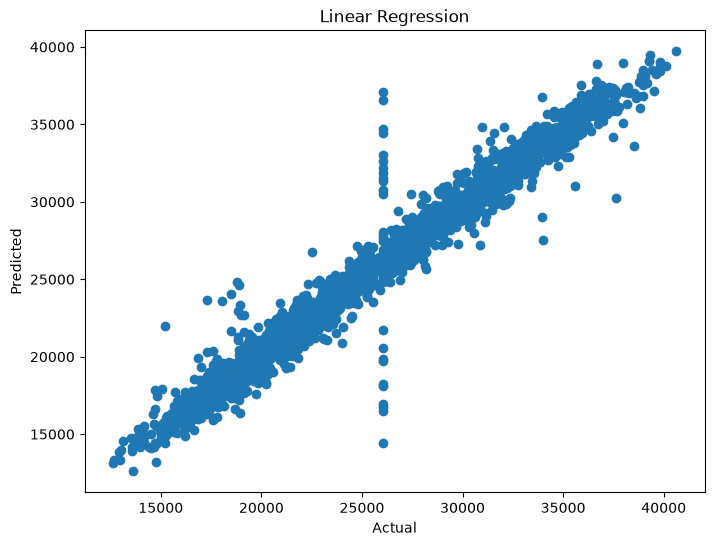

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Linear Regression")

plt.show()

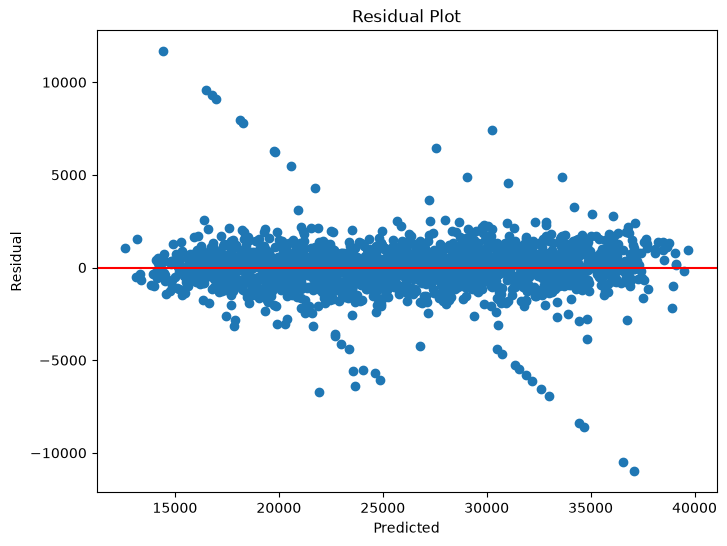

In [19]:
residual = y_test - lr_pred

plt.figure(figsize=(8,6))

plt.scatter(lr_pred, residual)

plt.axhline(0,color="red")

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [20]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 :", r2_score(y_test, rf_pred))

MAE : 308.8170748448661
RMSE : 902.1025292525335
R2 : 0.979928568431651


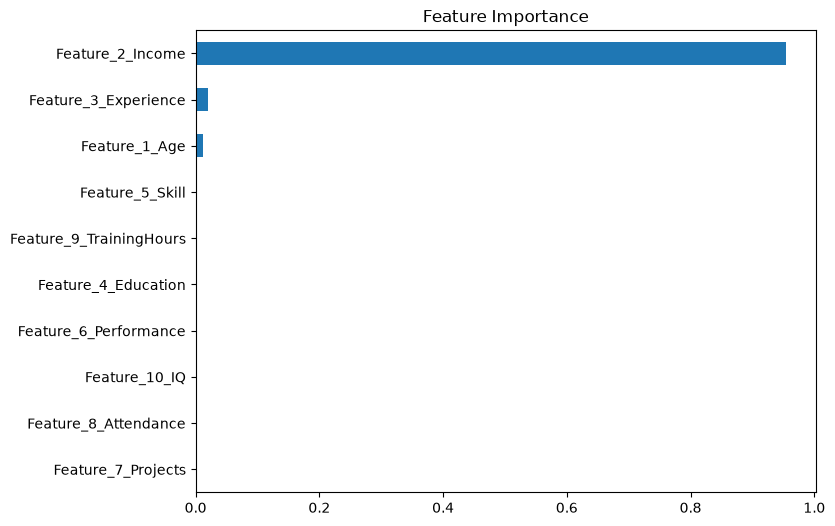

In [21]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()

In [24]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Features only
X = df.drop("Target", axis=1)

# Fill missing values
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(X_scaled.shape)

(10050, 10)


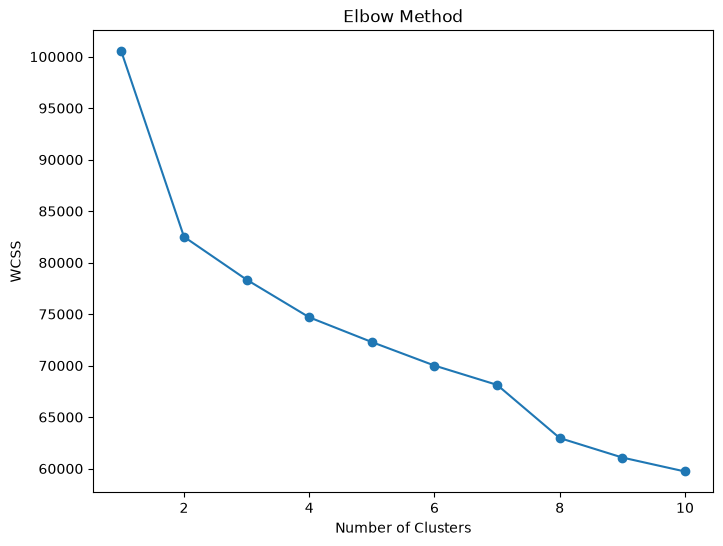

In [25]:
wcss = []

for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [26]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

In [27]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.10961943634872974


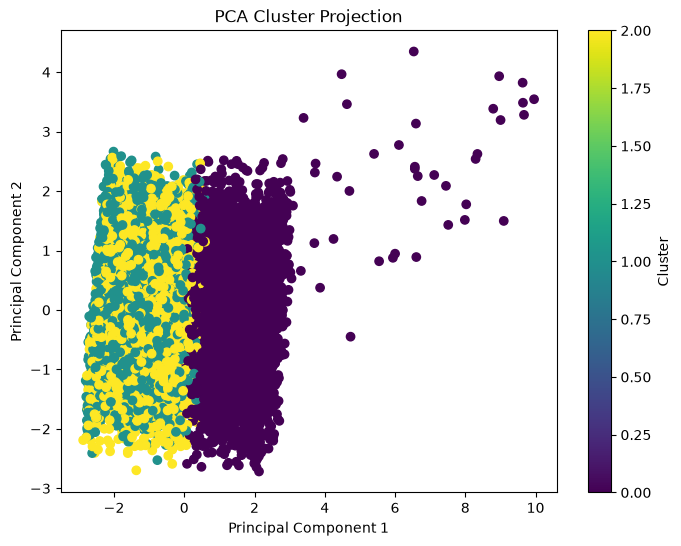

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Cluster Projection")

plt.colorbar(label="Cluster")

plt.show()

In [29]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print(importance)

Feature_2_Income           0.954376
Feature_3_Experience       0.020566
Feature_1_Age              0.012107
Feature_5_Skill            0.002909
Feature_9_TrainingHours    0.001882
Feature_4_Education        0.001830
Feature_6_Performance      0.001768
Feature_10_IQ              0.001543
Feature_8_Attendance       0.001519
Feature_7_Projects         0.001499
dtype: float64


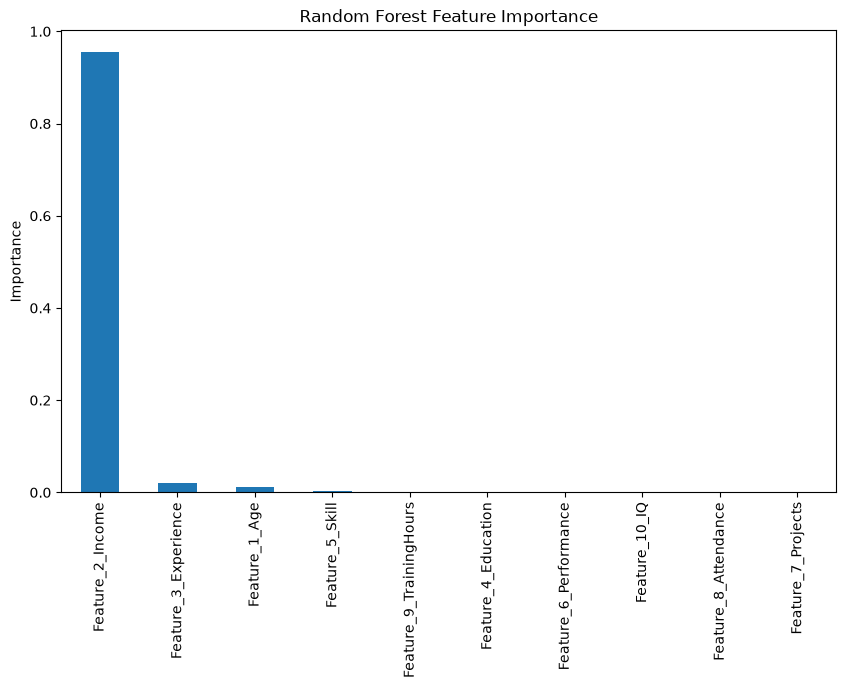

In [30]:
plt.figure(figsize=(10,6))

importance.plot(kind="bar")

plt.title("Random Forest Feature Importance")

plt.ylabel("Importance")

plt.show()

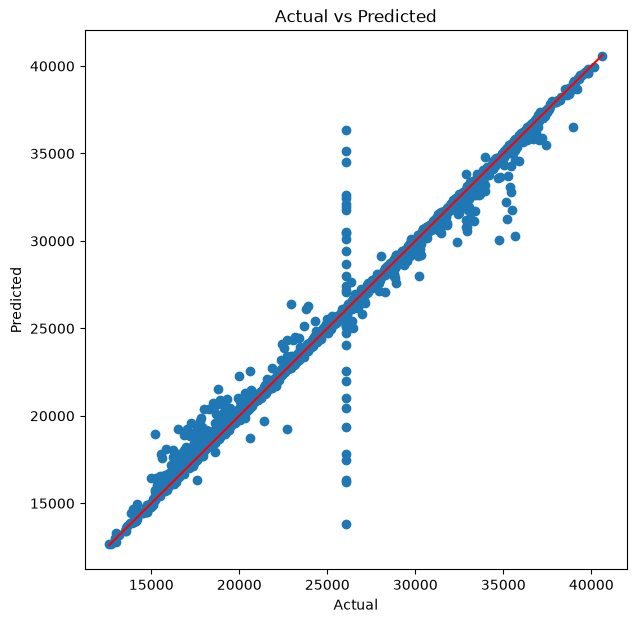

In [31]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

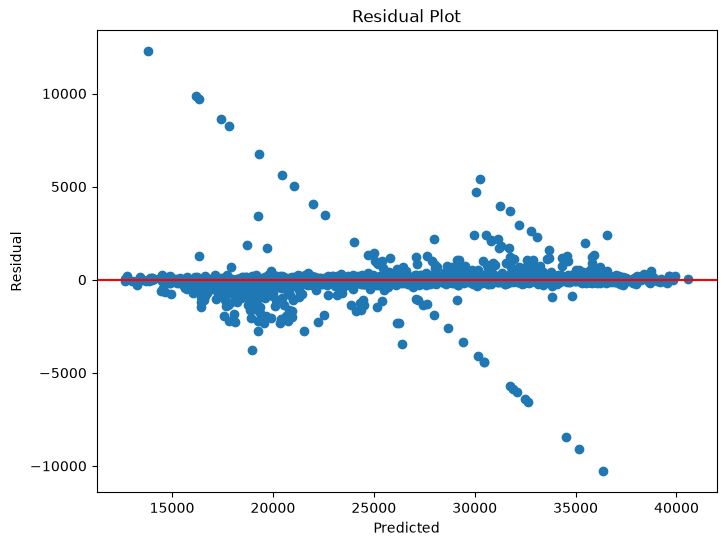

In [32]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,6))

plt.scatter(rf_pred, residuals)

plt.axhline(0, color="red")

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [33]:
cluster_df = df.copy()

cluster_df["Cluster"] = clusters

cluster_df.groupby("Cluster").mean()

,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ,Target
Cluster,,,,,,,,,,,
0,51.291543,218049.741360,28.908383,75.031473,70.206024,75.433699,10.722629,80.159007,107.888249,114.599816,31947.247054
1,30.833271,137659.372567,8.534314,73.064808,69.544428,73.734563,10.893681,80.684289,56.659805,115.067319,21005.535253
2,31.141289,140648.795665,8.888339,76.974323,69.670183,75.795745,10.173882,79.446290,154.048273,115.521201,21431.682167
